In [1]:
import sys
from pathlib import Path

import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import importlib
import xarray as xr


plt.style.use('../plotstyling.mplstyle')

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import plot_utils

In [2]:
with open("../../../DataStorage/AWS/Arctic/arctic_trainings/AWS_test_set_retrievals_arctic_2026-04-17.pickle", 'rb') as file:
    retrieval_dict_20260417 = pickle.load(file)

with open("../../../DataStorage/AWS/Arctic/arctic_trainings/AWS_test_set_retrievals_arctic_2026-09-28.pickle", 'rb') as file:
    retrieval_dict_20260928 = pickle.load(file)

with open("../../../DataStorage/AWS/AWS_test_set_retrievals_2025-11-26.pickle", 'rb') as file:
    retrieval_dict_chip = pickle.load(file)

In [22]:
fwp_bins = np.concatenate([
    [0],
    np.logspace(np.log10(1e-3), np.log10(1e2), 100),
])
lwp_bins = np.concatenate([
    [0],
    np.logspace(np.log10(1e-3), np.log10(1e1), 100),
])
zm_bins = np.linspace(0, 9000, 50)
dm_bins = np.linspace(0, 0.0015, 50)
lat_bins = np.linspace(-70, 70, 70)

units = {
    "fwp": "kg m$^{-2}$",
    "iwc": "kg m$^{-3}$",
    "zm": "km",
    "dm": "$\mu$m",
    "slwp": "kg m$^{-2}$",
}

# filtering for zm and dm
fwp_sensitivity_idxs = np.where(retrieval_dict_20260417["fwp_true"] > 1e-2)[0]
fwp_sensitivity_idxs_20260928 = np.where(retrieval_dict_20260928["fwp_true"] > 1e-2)[0]

## Calibration plots

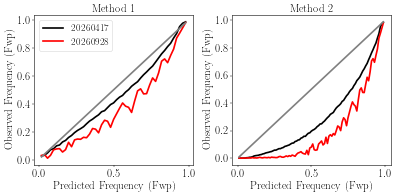

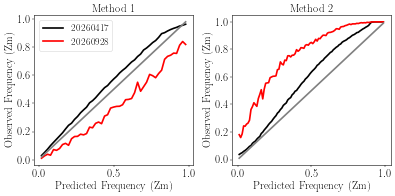

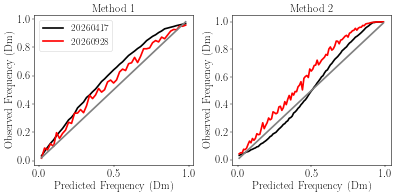

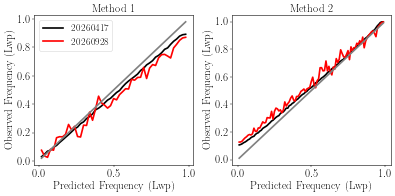

In [4]:
n_quantiles = 99
quantiles = np.linspace(0.01, 0.99, n_quantiles)
min_fwp = 1e-2   # only cases with true FWP above this

# each dataset: retrieval dict, colour, legend label
datasets = [
    (retrieval_dict_20260417, "k", "20260417"),
    (retrieval_dict_20260928, "red", "20260928"),
]

for var in ["fwp", "zm", "dm", "lwp"]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    for d, color, label in datasets:
        mask = d["fwp_true"] > min_fwp
        q = d[f"{var}_quantiles"][mask]
        true = d[f"{var}_true"][mask]

        intervals, fractions_1 = plot_utils.calibration(q, true, quantiles)
        fractions_2 = plot_utils.calibration_type_2(q, true, quantiles)

        ax1.plot(intervals, fractions_1, color=color, label=label)
        ax2.plot(quantiles, fractions_2, color=color, label=label)

    ax1.plot(intervals, intervals, color="gray")
    ax2.plot(quantiles, quantiles, color="gray")

    for ax, title in [(ax1, "Method 1"), (ax2, "Method 2")]:
        ax.set_xlabel(f"Predicted Frequency ({var.capitalize()})")
        ax.set_ylabel(f"Observed Frequency ({var.capitalize()})")
        ax.set_title(title)
    ax1.legend()

    fig.tight_layout()
    plt.savefig(f"../figures/test_set_retrievals/training_calibration_{var}.png",
                dpi=400, facecolor="white")

## Recovery plots

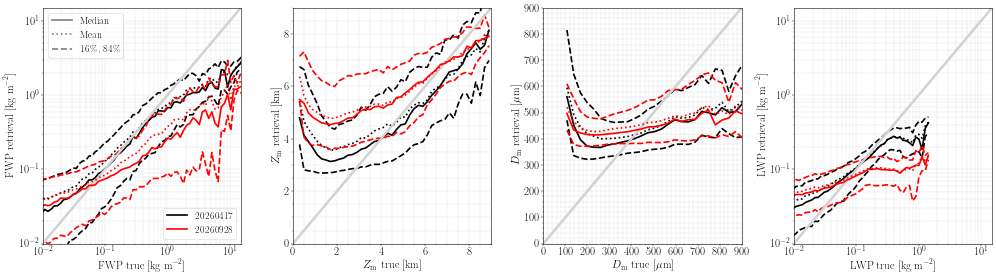

In [5]:
datasets = [
    (retrieval_dict_20260417, fwp_sensitivity_idxs, "k", "20260417"),
    (retrieval_dict_20260928, fwp_sensitivity_idxs_20260928, "red", "20260928"),
]

wp_units = r"[$\mathrm{kg \; m}^{-2}$]"

panels = [
    ("fwp", 1,    fwp_bins, False, "FWP",               wp_units,        [1e-2, 1.5e1], True,  None),
    ("zm",  1e3,  zm_bins,  True,  r"$Z_{\mathrm{m}}$", "[km]",          [0.5, 9],      False, np.arange(0, 9, 2)),
    ("dm",  1e-6, dm_bins,  True,  r"$D_{\mathrm{m}}$", r"[$\mu$m]",     [0, 900],      False, np.linspace(0, 900, 10)),
    ("lwp", 1,    fwp_bins, False, "LWP",               wp_units,        [1e-2, 1.5e1], True,  None),
]

fig, axes = plt.subplots(1, 4, figsize=(25, 7))

for ax, (var, scale, bins, use_sens, name, units, lims, log, ticks) in zip(axes, panels):
    for d, sens_idxs, color, _ in datasets:
        idx = sens_idxs if use_sens else slice(None)
        plot_utils.plot_true_vs_retrieval(
            d[f"{var}_true"][idx] / scale,
            d[f"{var}_mean"][idx] / scale,
            d[f"{var}_quantiles"][idx] / scale,
            var,
            ax,
            bins / scale,
            plot_all_quantiles=False,
            color=color,
            label=None,
        )

    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlabel(f"{name} true {units}")
    ax.set_ylabel(f"{name} retrieval {units}")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    if ticks is not None:
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)

style_handles = [
    Line2D([], [], color="gray", ls="-", label="Median"),
    Line2D([], [], color="gray", ls=":", label="Mean"),
    Line2D([], [], color="gray", ls="--", label=r"16\%, 84\%"),
]
axes[0].add_artist(axes[0].legend(handles=style_handles, loc="upper left"))

dataset_handles = [Line2D([], [], color=c, ls="-", label=lab) for _, _, c, lab in datasets]
axes[0].legend(handles=dataset_handles, loc="lower right")

fig.tight_layout()

plt.savefig("../figures/test_set_retrievals/recovery_plots_arctic.pdf", facecolor="white")
plt.savefig("../figures/test_set_retrievals/recovery_plots_arctic.png", dpi=400, facecolor="white")

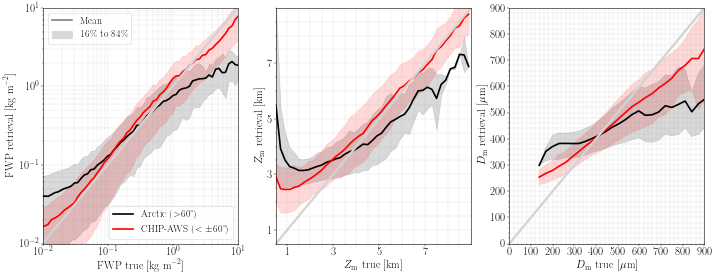

In [8]:
datasets = [
    (retrieval_dict_20260417, "k", r"Arctic ($>$60$^{\circ}$)"),
    (retrieval_dict_chip, "red", r"CHIP-AWS ($<\pm$60$^{\circ}$)"),
]

wp_units = r"[$\mathrm{kg \; m}^{-2}$]"

panels = [
    ("fwp", 1,    fwp_bins, None, "FWP",               wp_units,    [1e-2, 1e1],   True,  None),
    ("zm",  1e3,  zm_bins,  0.1,  r"$Z_{\mathrm{m}}$", "[km]",      [0.5, 9],      False, np.arange(1, 9, 2)),
    ("dm",  1e-6, dm_bins,  0.1,  r"$D_{\mathrm{m}}$", r"[$\mu$m]", [0, 900],      False, np.linspace(0, 900, 10)),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (var, scale, bins, min_fwp, name, units, lims, log, ticks) in zip(axes, panels):
    bins = bins / scale
    centres = bins[:-1] + np.diff(bins) / 2

    for d, color, _ in datasets:
        keep = d["fwp_true"] > min_fwp if min_fwp is not None else slice(None)
        mean, q16, q84 = plot_utils.binned_mean_and_spread(d[f"{var}_true"][keep] / scale,
                                                d[f"{var}_mean"][keep] / scale, bins)
        ax.fill_between(centres, q16, q84, color=color, alpha=0.15)
        ax.plot(centres, mean, color=color, lw=3)

    ax.plot(bins, bins, lw=4, color="lightgrey")
    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlabel(f"{name} true {units}")
    ax.set_ylabel(f"{name} retrieval {units}")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    if ticks is not None:
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
    ax.minorticks_on()
    ax.grid(which="both", ls="dashed", color="grey", alpha=0.3)

style_handles = [
    Line2D([], [], color="gray", ls="-", label="Mean"),
    Patch(color="gray", alpha=0.3, label=r"16\% to 84\%"),
]
axes[0].add_artist(axes[0].legend(handles=style_handles, loc="upper left"))

dataset_handles = [Line2D([], [], color=c, label=lab) for _, c, lab in datasets]
axes[0].legend(handles=dataset_handles, loc="lower right")

fig.tight_layout()
plt.savefig("../figures/test_set_retrievals/recovery_plots_arctic_chip_comparison.pdf", facecolor="white")
plt.savefig("../figures/test_set_retrievals/recovery_plots_chip_comparison.png", dpi=400, facecolor="white")

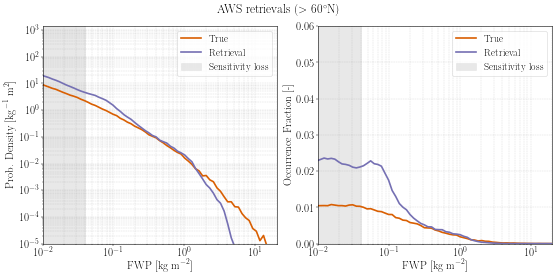

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

bins_centre = fwp_bins[:-1] + np.diff(fwp_bins) / 2

database_pdf, _ = np.histogram(retrieval_dict_20260417["fwp_true"], bins=fwp_bins, density=True)
pred_pdf, _     = np.histogram(retrieval_dict_20260417["fwp_mean"], bins=fwp_bins, density=True)

ax1.plot(bins_centre, database_pdf, color="C1", label="True")
ax1.plot(bins_centre, pred_pdf,     color="C2", label="Retrieval")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylim(bottom=1e-5)
ax1.set_xlim([1e-2, 2e1])
ax1.set_xticks([1e-2, 1e-1, 1e0, 1e1])
ax1.set_ylabel(r"Prob. Density [$\mathrm{kg}^{-1} \; \mathrm{m}^{2}$]")
ax1.set_xlabel(r"FWP [$\mathrm{kg \; m}^{-2}$]")
ax1.grid(which="both", ls="dashed", color="grey", alpha=0.3)

# ── Occurrence fraction / PMF ─────────────────────────────────────────────────
true_counts, _ = np.histogram(retrieval_dict_20260417["fwp_true"], bins=fwp_bins)
pred_counts, _ = np.histogram(retrieval_dict_20260417["fwp_mean"], bins=fwp_bins)

# total counts INCLUDING zeros
true_total = len(retrieval_dict_20260417["fwp_true"])
pred_total = len(retrieval_dict_20260417["fwp_mean"])

true_pmf = true_counts / true_total   # now sums to < 1 if zeros exist
pred_pmf = pred_counts / pred_total

ax2.plot(bins_centre, true_pmf, color="C1", label="True")
ax2.plot(bins_centre, pred_pmf, color="C2", label="Retrieval")
ax2.set_xscale("log")
#ax2.set_yscale("log")
ax2.set_ylim([0, 0.06])
ax2.set_xlim([1e-2, 2e1])
ax2.set_xticks([1e-2, 1e-1, 1e0, 1e1])
ax2.set_ylabel("Occurrence Fraction [-]")
ax2.set_xlabel(r"FWP [$\mathrm{kg \; m}^{-2}$]")
ax2.grid(which="both", ls="dashed", color="grey", alpha=0.3)

for ax in (ax1, ax2):
    ax.axvspan(1e-4, 4e-2, color="lightgrey", alpha=0.5, zorder=0, label="Sensitivity loss")

ax1.legend(loc="upper right")
ax2.legend(loc="upper right")

fig.suptitle("AWS retrievals ($>$ 60$^{\circ}$N)", fontsize=22)
fig.tight_layout()
plt.savefig("../figures/test_set_retrievals/AWS_FWP_distribution_arctic.pdf", facecolor="white")
plt.savefig("../figures/test_set_retrievals/AWS_FWP_distribution_arctic.png", dpi=400, facecolor="white")

/home/eleanor/Documents/Research/PHD/Projects/AWS_Arctic/scripts/plot_utils.py:171: RuntimeWarning: invalid value encountered in scalar divide
  mean_database[lat_bin] = np.nansum(selected_var_db*selected_iwp_db) / np.nansum(selected_iwp_db)
/home/eleanor/Documents/Research/PHD/Projects/AWS_Arctic/scripts/plot_utils.py:181: RuntimeWarning: invalid value encountered in scalar divide
  mean_pred[lat_bin] = np.nansum(selected_var_pred*selected_iwp_pred) / np.nansum(selected_iwp_pred)
/home/eleanor/Documents/Research/PHD/Projects/AWS_Arctic/scripts/plot_utils.py:171: RuntimeWarning: invalid value encountered in scalar divide
  mean_database[lat_bin] = np.nansum(selected_var_db*selected_iwp_db) / np.nansum(selected_iwp_db)
/home/eleanor/Documents/Research/PHD/Projects/AWS_Arctic/scripts/plot_utils.py:181: RuntimeWarning: invalid value encountered in scalar divide
  mean_pred[lat_bin] = np.nansum(selected_var_pred*selected_iwp_pred) / np.nansum(selected_iwp_pred)


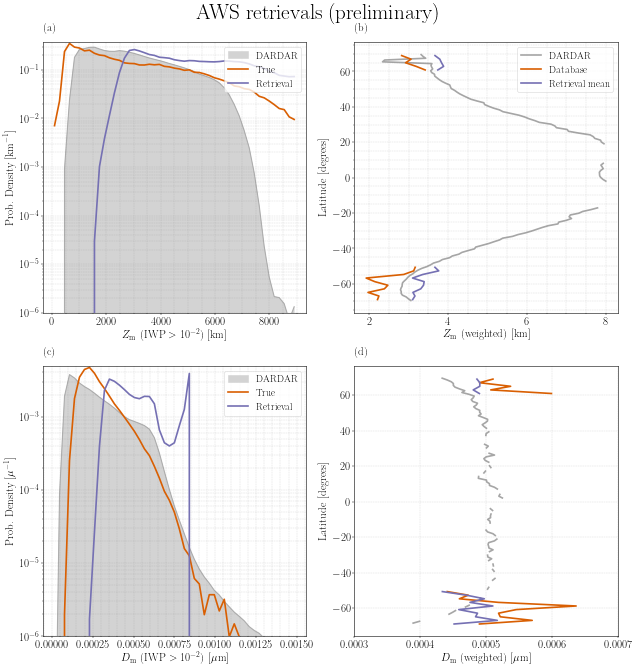

In [23]:
fig, ((ax1, ax3), (ax2, ax4)) = plt.subplots(2, 2, figsize=(16, 17))

plot_variable = "zm"
bins = zm_bins
bins_centre = bins[:-1] + np.diff(bins) / 2

# ********** Zm - Total distribution **********

plot_utils.plot_overall_distribution(retrieval_dict_20260417, "zm", ax1, zm_bins, "../../../DataStorage/DARDAR/DARDAR_Zm_dist.pkl", factor=1000)

ax1.set_ylim(bottom=1e-6)
ax1.set_yscale("log")
ax1.set_ylabel("Prob. Density [$\mathrm{km}^{-1}$]")
ax1.set_xlabel(r"$Z_{\mathrm{m}}$ (IWP $> 10^{-2}$) [km]")
ax1.minorticks_on()
ax1.grid(which="both", ls="dashed", color="grey", alpha=0.3)


# ********** Zm - Zonal mean, weighted with IWP **********

plot_utils.plot_zonal_mean_weighted(
    retrieval_dict_20260417,
    "zm",
    ax3,
    lat_bins,
    "../../../DataStorage/DARDAR/DARDAR_Zm_zonalmean_weighted.pkl")

ax3.legend(loc="best")
ax3.set_xticks([2000, 4000, 6000, 8000])
ax3.set_xticklabels([2, 4, 6, 8])
ax3.set_xlabel(r"$Z_{\mathrm{m}}$ (weighted) [km]")


# ********** Dm - Total distribution **********

plot_utils.plot_overall_distribution(retrieval_dict_20260417, "dm", ax2, dm_bins, "../../../DataStorage/DARDAR/DARDAR_Dm_dist.pkl", factor=1e-6)

ax2.set_ylim(bottom=1e-6)
ax2.set_yscale("log")
ax2.set_ylabel(r"Prob. Density [$\mu^{-1}$]")
ax2.set_xlabel(r"$D_{\mathrm{m}}$ (IWP $> 10^{-2}$) [$\mu$m]")
ax2.minorticks_on()
ax2.grid(which="both", ls="dashed", color="grey", alpha=0.3)


# ********** Dm - Zonal mean, weighted with IWP **********

plot_utils.plot_zonal_mean_weighted(
    retrieval_dict_20260417,
    "dm",
    ax4,
    lat_bins,
    "../../../DataStorage/DARDAR/DARDAR_Dm_zonalmean_weighted.pkl")

ax4.set_xlim([0.0003, 0.0007])
#ax4.set_xticks(np.array([0.0003, 0.0004, 0.0005, 0.0006]))
ax4.minorticks_off()  # Disable minor ticks entirely

#ax4.set_xticklabels(
#    np.round(np.array([0.0003, 0.0004, 0.0005, 0.0006]) / 1e-6).astype(int)
#)
ax4.set_xlabel(r"$D_{\mathrm{m}}$ (weighted) [$\mu$m]")

ax1.set_title("(a)", loc="left", pad=20)
ax3.set_title("(b)", loc="left", pad=20)
ax2.set_title("(c)", loc="left", pad=20)
ax4.set_title("(d)", loc="left", pad=20)

fig.suptitle("AWS retrievals (preliminary)")
fig.tight_layout()

plt.savefig(f"../figures/test_set_retrievals/AWS_Dm_Zm_distribution.pdf", facecolor="white")


In [21]:
dardar = pickle.load(open("../../../DataStorage/DARDAR/DARDAR_Zm_dist.pkl", "rb"))
print(len(dardar), len(zm_bins) - 1)

49 45
